In [40]:
from pathlib import Path

from imagematerials.__main__ import export_summary_netcdf, simulate_stocks
from imagematerials.vehicles.preprocessing import (
    preprocessing,
)
from imagematerials.util import import_from_netcdf, export_to_netcdf
from imagematerials.model import GenericMainModel, GenericMaterials, GenericStocks
from imagematerials.factory import ModelFactory
from imagematerials.maintenance import Maintenance
from imagematerials.concepts import vehicle_knowledge_graph

import prism


In [41]:
base_dir = "../data/raw"
prep_fp = Path("prep_vema.nc")

In [42]:
if not prep_fp.is_file():
    _, orig_prep_data = preprocessing(base_dir)
    export_to_netcdf(orig_prep_data, prep_fp)
prep_data = import_from_netcdf(prep_fp)
prep_data["weights"] = prep_data.pop("vehicle_weights")

In [43]:
import pandas as pd
from imagematerials.util import dataset_to_array

# Copy dimensiomns from material_fractions for xr_maintenance_material
materials = prep_data['material_fractions'].coords["material"]
types = prep_data['material_fractions'].coords["Type"]

maintenance_material_pd : pd.DataFrame = pd.read_csv(
    "../data/raw/vehicles/standard_data/all_vehicle_maintenance_image.csv", index_col=0)

maintenance_material_pd['Li'] = 0
maintenance_material_pd['Mn'] = 0
maintenance_material_pd['Ni'] = 0
maintenance_material_pd['Ti'] = 0

stacked_maintenance_material = maintenance_material_pd.set_index("Type").stack().rename_axis(index=["Type", "material"]).reset_index(name="value")

stacked_maintenance_material = stacked_maintenance_material.set_index(["Type", "material"])

stacked_maintenance_material_xr = stacked_maintenance_material.to_xarray()
maintenance_material = dataset_to_array(stacked_maintenance_material_xr, ["Type", "material"], [])


In [44]:
maintenance_material_pd

,Type,Aluminium,Co,Cu,Glass,Pb,Nd,Plastics,Rubber,Steel,Wood,Li,Mn,Ni,Ti
0,Cars,0.106571,0.008707,0.001471,0.001182,0.026999,0.000138,0.013595,0.076862,0.125311,0.000000e+00,0,0,0,0
1,Heavy Freight Trucks,0.010207,0.000000,0.004223,0.000000,0.003239,0.000000,0.002758,0.000000,0.097935,0.000000e+00,0,0,0,0
2,High Speed Trains,0.350176,0.000000,0.060030,0.000005,0.000000,0.000000,0.002540,0.015051,0.590297,9.826590e-07,0,0,0,0
3,Light Commercial Vehicles,0.000000,0.000000,0.000300,0.000000,0.013000,0.000000,0.012000,0.233000,0.022000,0.000000e+00,0,0,0,0
4,Medium Freight Trucks,0.019465,0.000000,0.006392,0.000000,0.003750,0.000000,0.003225,0.000000,0.186517,0.000000e+00,0,0,0,0
5,Midi Buses,0.003829,0.000000,0.001358,0.000000,0.000000,0.000000,0.000745,0.000000,0.043537,0.000000e+00,0,0,0,0
6,Regular Buses,0.003224,0.000000,0.001288,0.000000,0.000000,0.000000,0.000745,0.000000,0.038166,0.000000e+00,0,0,0,0
7,Trains,0.121613,0.000000,0.020848,0.011215,0.000000,0.000000,0.047580,0.015881,0.205006,8.090523e-03,0,0,0,0


In [45]:
import numpy as np
import xarray as xr
from scipy.stats import norm

# Define expected value of folded normal distribution
def expected_folded_norm(c, scale):
    term1 = np.sqrt(2 / np.pi) * np.exp(-c**2 / 2)
    term2 = c * (1 - 2 * norm.cdf(-c))
    return scale * (term1 + term2)

# Vectorized function to apply over the last axis (ScipyParam)
def compute_expected_lifetime(params):
    c = params[0]
    scale = params[1]
    return expected_folded_norm(c, scale)

selected_params = prep_data["lifetimes"]["folded_norm"].sel(Time=2020).drop("Time")

# Apply over the xarray DataArray
expected_lifetimes = xr.apply_ufunc(
    compute_expected_lifetime,
    selected_params,
    input_core_dims=[["ScipyParam"]],
    output_core_dims=[[]],
    vectorize=True,
    output_dtypes=[float]
)




C:\Users\5982758\AppData\Local\Temp\ipykernel_4272\1169275857.py:17: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  selected_params = prep_data["lifetimes"]["folded_norm"].sel(Time=2020).drop("Time")


In [46]:
maintenance_material_per_year = (maintenance_material / expected_lifetimes)
maintenance_material_per_year_broadcasted = vehicle_knowledge_graph.rebroadcast_xarray_impute(
    maintenance_material_per_year, types.values)

prep_data["maintenance_material_fractions"] = maintenance_material_per_year_broadcasted

In [47]:
# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

In [48]:
# Define the coordinates of all dimensions.
Region = list(prep_data["stocks"].coords["Region"].values)
Time = [t for t in complete_timeline]
Cohort = Time
Type = list(prep_data["stocks"].coords["Type"].values)
material = list(prep_data["material_fractions"].coords["material"].values)

# Create
main_model_normal = GenericMainModel(
    complete_timeline, Region=Region, Time=Time, Cohort=Cohort, Type=Type, prep_data=prep_data,
    compute_materials=True, compute_battery_materials=False, compute_maintenance_materials=True, 
    material=material)

In [49]:
main_model_normal.simulate(simulation_timeline)

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


...

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


In [50]:
main_model_factory = ModelFactory(
    prep_data, complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials
    ).add(Maintenance
    ).finish()

In [51]:
main_model_factory.simulate(simulation_timeline)

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


...

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


In [52]:
main_model_normal.stock_model.inflow[2020]

Magnitude,[[84910.37993477192 0.0 0.0 ... 0.0 0.0 0.0] [47794.55037900992 0.0 0.0 ... 0.0 16.08411805133079 0.0] [0.0 0.0 0.0 ... 0.0 54.02363587764103 0.0] ... [202629.71414214745 181986.79723958857 4.5406270070348796e-08 ... 0.0 13.159979660822387 0.0] [0.0 312917.2036203183 0.0037196248952304704 ... 0.0 0.0 0.12947389563773015] [3213643.6784069687 478686.0859866794 0.20921506729603268 ... 0.0 29.680070308214113 0.053579670116025824]]
Units,count


In [53]:
# Sum general inflow over Region
inflow_total = main_model_normal.material_model.inflow_materials[2020].sum(dim="Region")

# Sum maintenance inflow over Region and materials
inflow_maintenance = main_model_normal.maintenance_model.inflow_maintenance[2020].sum(dim=["Region"])#.sel(Type="Trains")

# Convert to pandas Series
inflow_total_pd = inflow_total.to_series()
inflow_maintenance_pd = inflow_maintenance.to_series()

# Combine into a DataFrame
df_plot = pd.DataFrame({
    "Total Inflow": inflow_total_pd,
    "Maintenance Inflow": inflow_maintenance_pd
})


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


In [ ]:
train_maintenance =  main_model_normal.material_model.inflow_materials[2020].sum(dim="Region"
                        ).sel({"Type": ["Trains", "High Speed Trains"]}).drop(["Time"]).to_series()
train_production = main_model_normal.maintenance_model.inflow_maintenance[2020].sum(dim="Region"
                        ).sel({"Type": ["Trains", "High Speed Trains"]}).drop(["Time"]).to_series()
train_maintenance = train_maintenance.rename_axis(index={"material": "materials"})

# Align and combine into DataFrame
combined = pd.DataFrame({
    "Production": train_production,
    "Maintenance": train_maintenance
}).fillna(0)

# Drop rows where both are zero
df_plot = combined[(combined["Production"] != 0) | (combined["Maintenance"] != 0)]



c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


Production   Maintenance
time Type                                                   
1961 Trains            Aluminium  3.491786e+07  3.161497e+09
                       Cu         5.985919e+06  1.406896e+07
                       Glass      3.219962e+06  3.718226e+07
                       Plastics   1.366117e+07  2.100295e+08
                       Rubber     4.559868e+06  0.000000e+00
...                                        ...           ...
2060 High Speed Trains Glass      1.776671e+03  1.125526e+07
                       Plastics   9.757697e+05  1.995526e+07
                       Rubber     5.782774e+06  0.000000e+00
                       Steel      2.267951e+08  3.628451e+08
                       Wood       3.775425e+02  0.000000e+00

[1323 rows x 2 columns]

In [ ]:
train_production =  main_model_normal.material_model.inflow_materials.to_array().sum(dim="Region"
                        ).sel(Type= "High Speed Trains").drop(["Type"])#.sel({"Type": ["Trains", "High Speed Trains"]})
train_maintenance = main_model_normal.maintenance_model.inflow_maintenance.to_array().sum(dim="Region"
                        ).sel(Type= "High Speed Trains").drop(["Type"])#.sel({"Type": ["Trains", "High Speed Trains"]})
train_stock = main_model_normal.material_model.stock_by_cohort_materials.sum(dim="Region"
                        ).sel(Type= "High Speed Trains").drop(["Type"])

train_maintenance

C:\Users\5982758\AppData\Local\Temp\ipykernel_4272\1667688979.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ).sel(Type= "High Speed Trains").drop(["Type"])#.sel({"Type": ["Trains", "High Speed Trains"]})
C:\Users\5982758\AppData\Local\Temp\ipykernel_4272\1667688979.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ).sel(Type= "High Speed Trains").drop(["Type"])#.sel({"Type": ["Trains", "High Speed Trains"]})
C:\Users\5982758\AppData\Local\Temp\ipykernel_4272\1667688979.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ).sel(Type= "High Speed Trains").drop(["Type"])


Magnitude,[[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [123446093.1285374 0.0 21162187.393463556 ... 208094842.70239162 0.0 346.412376355765] [128804904.36869688 0.0 22080840.74891947 ... 217128267.36437482 0.0 361.45018345924865] [134539491.49667272 0.0 23063912.828001045 ... 226795142.80867693 0.0 377.5424866182707]]
Units,count


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


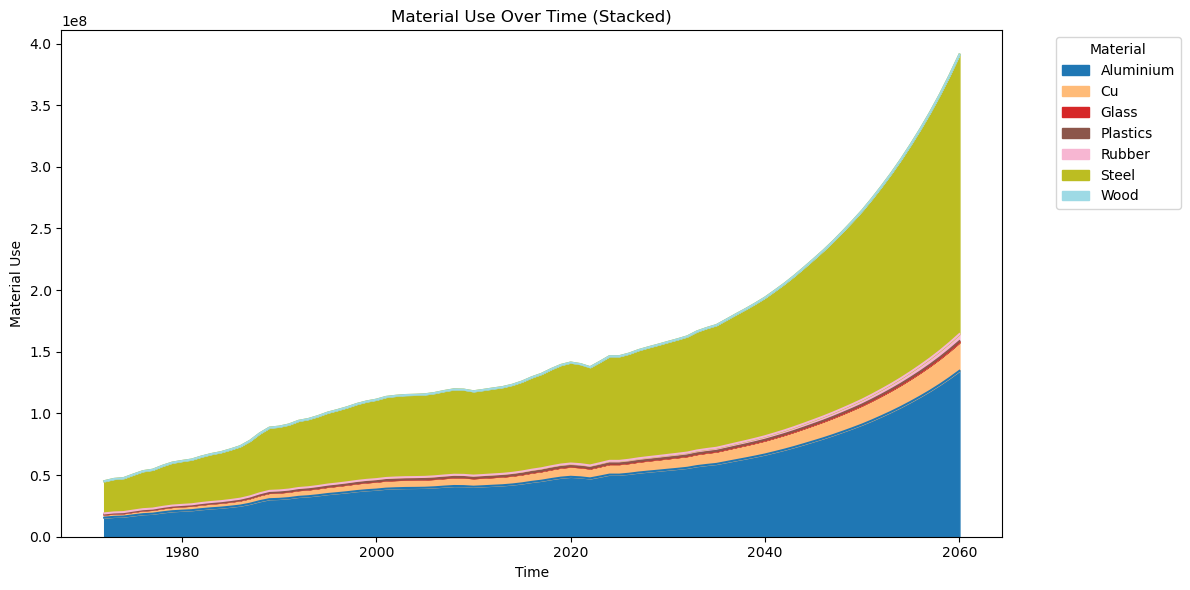

In [78]:
import matplotlib.pyplot as plt

# Convert to DataFrame
df = train_production.to_pandas()  # shape: (time, material)

# 1. Drop materials that are all zero
df = df.loc[:, (df != 0).any(axis=0)]

# 2. Filter from 1972 onward (assuming time is in datetime or integer years)
df = df[df.index >= 1972]

# Plot
df.plot.area(figsize=(12, 6), colormap='tab20')
plt.xlabel('Time')
plt.ylabel('Material Use')
plt.title('Material Use Over Time (Stacked)')
plt.legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


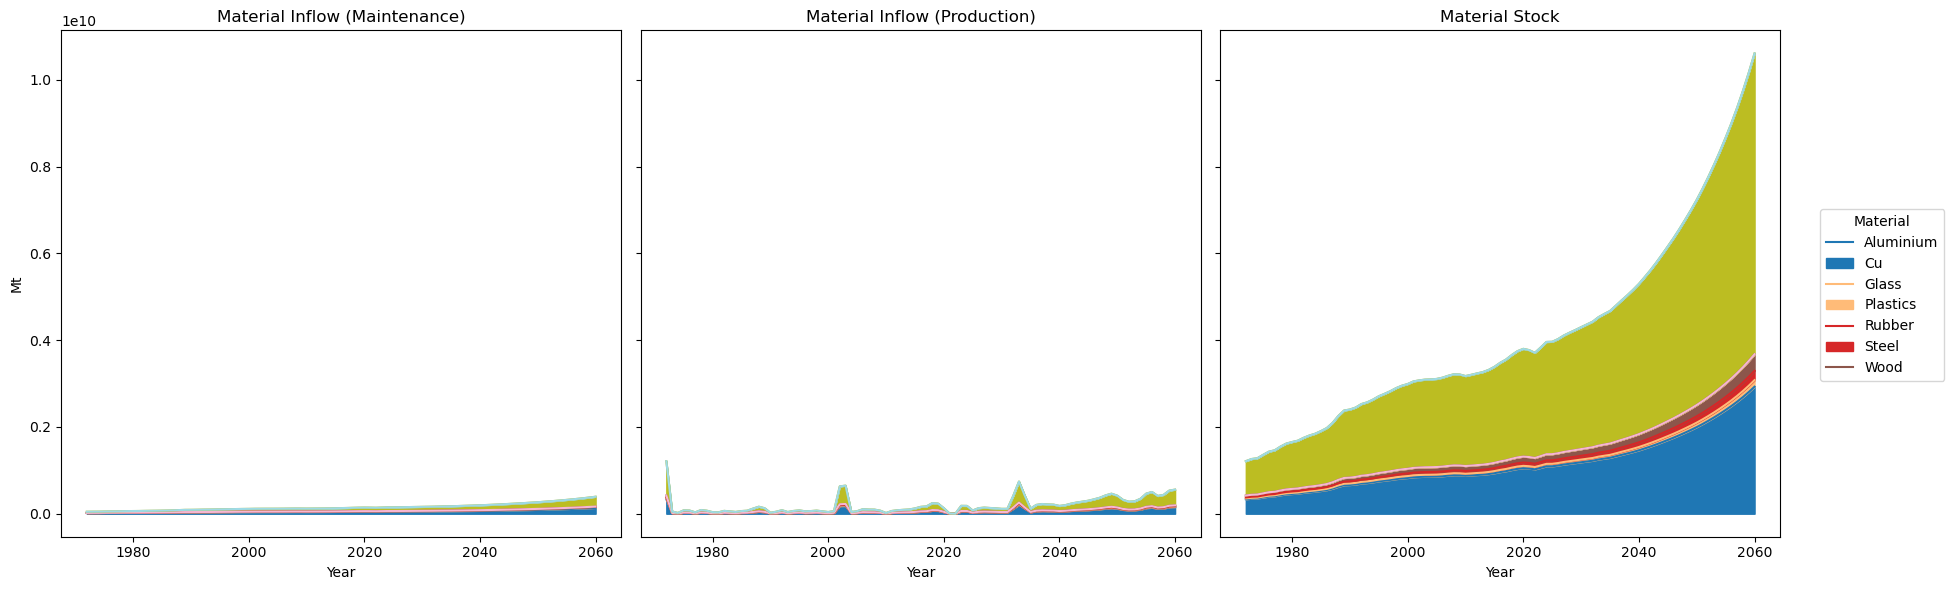

In [85]:
import matplotlib.pyplot as plt

# Step 1: Convert all to DataFrames
maintenance_df = train_maintenance.to_pandas()
production_df = train_production.to_pandas()
stock_df = train_stock.to_pandas()

# Step 2: Filter all materials where at least one of the three is non-zero
nonzero_materials = (
    (maintenance_df != 0).any(axis=0) |
    (production_df != 0).any(axis=0) |
    (stock_df != 0).any(axis=0)
)

# Apply mask to all three
maintenance_df = maintenance_df.loc[:, nonzero_materials]
production_df = production_df.loc[:, nonzero_materials]
stock_df = stock_df.loc[:, nonzero_materials]

# Step 3: Filter from 1972 onward
maintenance_df = maintenance_df[maintenance_df.index >= 1972]
production_df = production_df[production_df.index >= 1972]
stock_df = stock_df[stock_df.index >= 1972]

# Step 4: Plot in 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

maintenance_df.plot.area(ax=axes[0], colormap="tab20")
axes[0].set_title("Material Inflow (Maintenance)")
axes[0].set_xlabel("Year")

production_df.plot.area(ax=axes[1], colormap="tab20")
axes[1].set_title("Material Inflow (Production)")
axes[1].set_xlabel("Year")

stock_df.plot.area(ax=axes[2], colormap="tab20")
axes[2].set_title("Material Stock")
axes[2].set_xlabel("Year")

for ax in axes:
    ax.set_ylabel("Mt")
    ax.legend().remove()

# Add one shared legend outside the plot
fig.legend(maintenance_df.columns, title="Material", loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


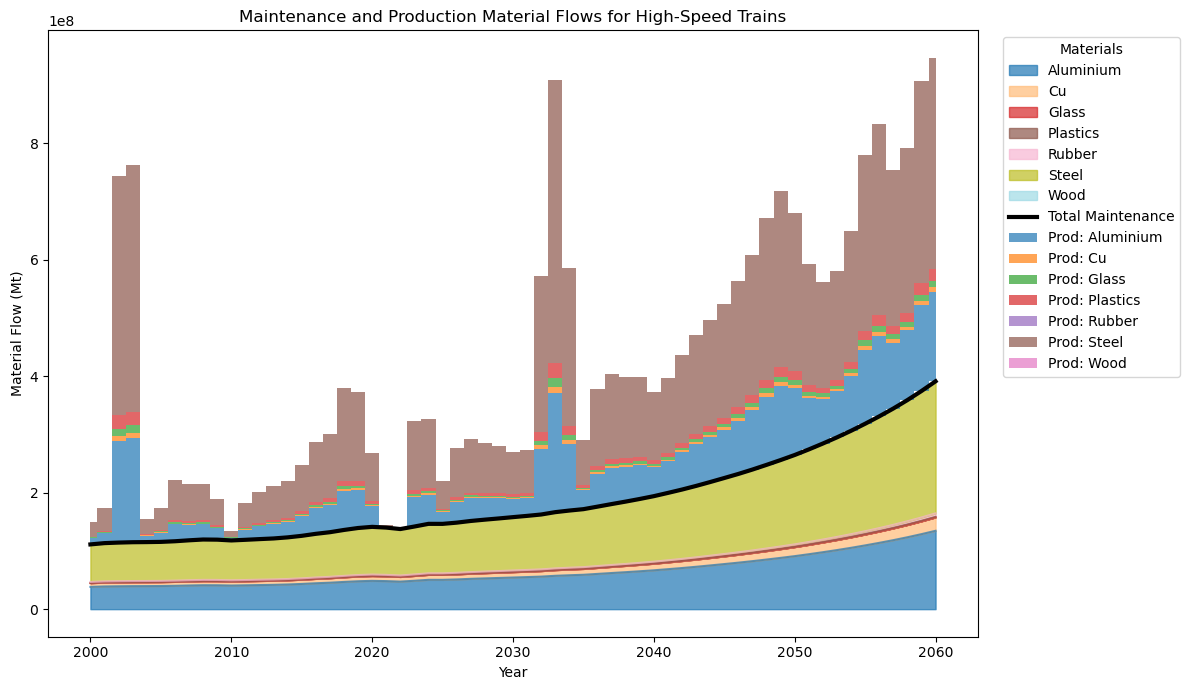

In [88]:
import matplotlib.pyplot as plt

# Convert to DataFrames
maintenance_df = train_maintenance.to_pandas()
production_df = train_production.to_pandas()
stock_df = train_stock.to_pandas()

# Filter out zero-only materials
nonzero_materials = (
    (maintenance_df != 0).any(axis=0) |
    (production_df != 0).any(axis=0) |
    (stock_df != 0).any(axis=0)
)

maintenance_df = maintenance_df.loc[:, nonzero_materials]
production_df = production_df.loc[:, nonzero_materials]

# Filter from 1972 onwards
maintenance_df = maintenance_df[maintenance_df.index >= 2000]
production_df = production_df[production_df.index >= 2000]

# Total maintenance sum (used for offset and line)
maintenance_total = maintenance_df.sum(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot maintenance materials as stacked area
maintenance_df.plot.area(ax=ax, stacked=True, colormap="tab20", alpha=0.7)
# Plot a thick line on top of maintenance total
ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=3, label="Total Maintenance")

# Plot production materials offset above maintenance
prod_bottom = maintenance_total.copy()
for material in production_df.columns:
    top = prod_bottom + production_df[material]
    ax.fill_between(
        production_df.index,
        prod_bottom,
        top,
        label=f"Prod: {material}",
        alpha=0.7,
        step="mid"
    )
    prod_bottom = top

# Final touches
ax.set_xlabel("Year")
ax.set_ylabel("Material Flow (Mt)")
ax.set_title("Maintenance and Production Material Flows for High-Speed Trains")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Materials")
plt.tight_layout()
plt.show()


In [89]:
train_production =  main_model_normal.material_model.inflow_materials.to_array().sum(dim="Region"
                        ).sel(Type= "Trains").drop(["Type"])#.sel({"Type": ["Trains", "High Speed Trains"]})
train_maintenance = main_model_normal.maintenance_model.inflow_maintenance.to_array().sum(dim="Region"
                        ).sel(Type= "Trains").drop(["Type"])#.sel({"Type": ["Trains", "High Speed Trains"]})
train_stock = main_model_normal.material_model.stock_by_cohort_materials.sum(dim="Region"
                        ).sel(Type= "Trains").drop(["Type"])

train_maintenance

C:\Users\5982758\AppData\Local\Temp\ipykernel_4272\3941001097.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ).sel(Type= "Trains").drop(["Type"])#.sel({"Type": ["Trains", "High Speed Trains"]})
C:\Users\5982758\AppData\Local\Temp\ipykernel_4272\3941001097.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ).sel(Type= "Trains").drop(["Type"])#.sel({"Type": ["Trains", "High Speed Trains"]})
C:\Users\5982758\AppData\Local\Temp\ipykernel_4272\3941001097.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ).sel(Type= "Trains").drop(["Type"])


Magnitude,[[0.0 0.0 0.0 ... 0.0 0.0 0.0] [34917859.83320192 0.0 5985918.82854889 ... 58861535.14739755 0.0 2322964.450260882] [35174608.80256371 0.0 6029932.937582338 ... 59294340.55289312 0.0 2340045.0712186825] ... [187111965.40681624 0.0 32076336.92688273 ... 315417313.11434746 0.0 12447911.926296912] [187205045.5756753 0.0 32092293.527258556 ... 315574219.68470985 0.0 12454104.228010612] [185519273.44754574 0.0 31803304.019579202 ... 312732489.5258628 0.0 12341955.63861848]]
Units,count


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


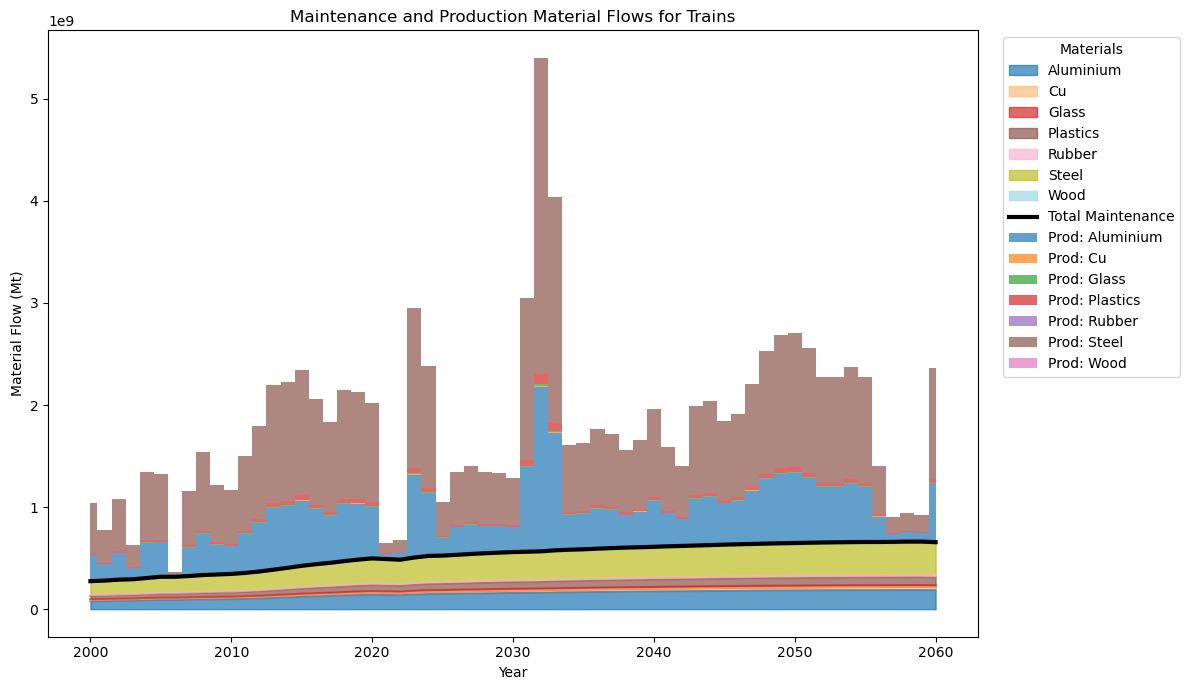

In [90]:
import matplotlib.pyplot as plt

# Convert to DataFrames
maintenance_df = train_maintenance.to_pandas()
production_df = train_production.to_pandas()
stock_df = train_stock.to_pandas()

# Filter out zero-only materials
nonzero_materials = (
    (maintenance_df != 0).any(axis=0) |
    (production_df != 0).any(axis=0) |
    (stock_df != 0).any(axis=0)
)

maintenance_df = maintenance_df.loc[:, nonzero_materials]
production_df = production_df.loc[:, nonzero_materials]

# Filter from 1972 onwards
maintenance_df = maintenance_df[maintenance_df.index >= 2000]
production_df = production_df[production_df.index >= 2000]

# Total maintenance sum (used for offset and line)
maintenance_total = maintenance_df.sum(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot maintenance materials as stacked area
maintenance_df.plot.area(ax=ax, stacked=True, colormap="tab20", alpha=0.7)
# Plot a thick line on top of maintenance total
ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=3, label="Total Maintenance")

# Plot production materials offset above maintenance
prod_bottom = maintenance_total.copy()
for material in production_df.columns:
    top = prod_bottom + production_df[material]
    ax.fill_between(
        production_df.index,
        prod_bottom,
        top,
        label=f"Prod: {material}",
        alpha=0.7,
        step="mid"
    )
    prod_bottom = top

# Final touches
ax.set_xlabel("Year")
ax.set_ylabel("Material Flow (Mt)")
ax.set_title("Maintenance and Production Material Flows for Trains")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Materials")
plt.tight_layout()
plt.show()


In [ ]:
# Sort by total inflow (optional)
df_plot = df_plot.sort_values("Production", ascending=False)

# Plot side-by-side bars with log scale
ax = df_plot.plot(kind="bar", figsize=(12, 6), color=["skyblue", "orange"])
ax.set_yscale("log")
ax.set_ylabel("Inflow [kg]")
ax.set_xlabel("Transport Type")
ax.set_title("Global Material Inflows by Type – 2020")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\5982758\AppData\Local\Temp\ipykernel_4272\830013958.py:74: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  prod_highspeed = main_model_normal.material_model.inflow_materials.to_array().sum(dim="Region").sel(Type="High Speed Trains").drop("Type").to_pandas()
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
C:\Users\5982758\AppData\Local\Temp\ipykernel_4272\830013958.py:75: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  maint_highspeed = main_model_normal.maintenance_model.inflow_maintenance.to_array().sum(dim="Region").sel(Type="High Speed Trains").drop("Type").to_pandas()
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downca

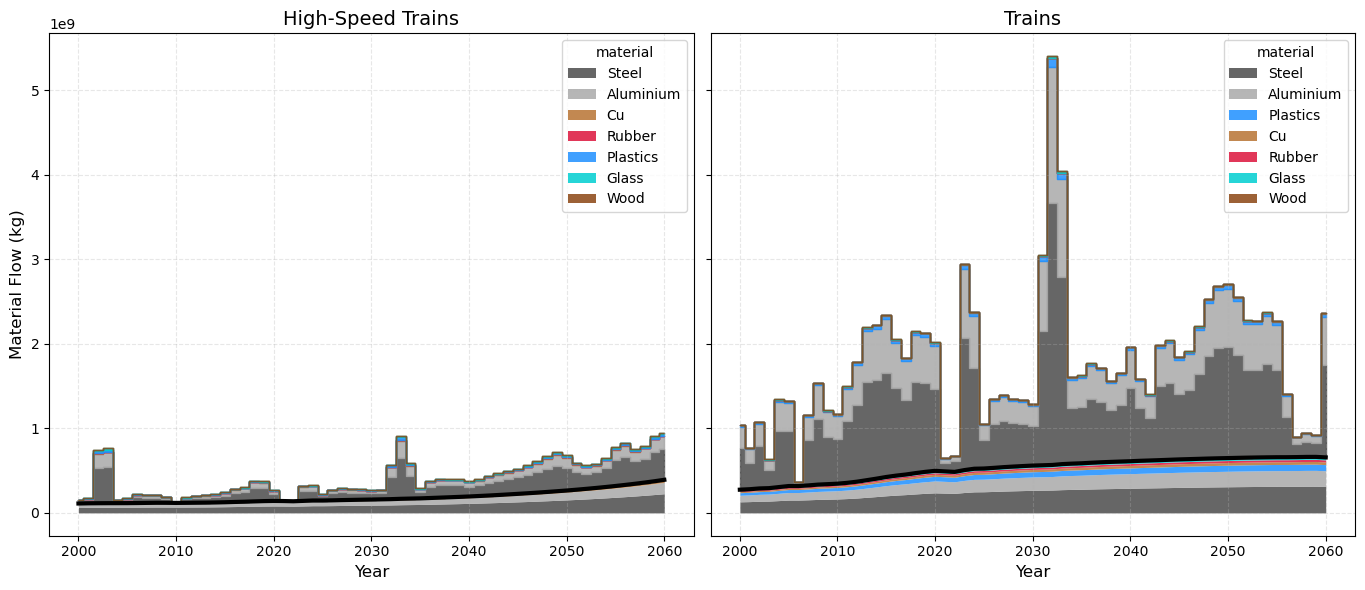

In [93]:
import matplotlib.pyplot as plt

# Define consistent colors
material_colors = {
    "Steel": "#4B4B4B",
    "Aluminium": "#A9A9A9",
    "Others": "#F0E68C",
    "Plastics": "#1E90FF",
    "Copper": "#B87333",
    "Rubber": "#DC143C",
    "Glass": "#00CED1",
    "Wood": "#8B4513",
    "Fluids": "#FF6347",
    "Lead": "#808080",
    "Neodymium": "#D2691E",
    "Cobalt": "#0047AB",
    "Cu": "#B87333"
}

# Helper function to sort columns by total sum
def sort_columns_by_sum(df):
    return df.loc[:, df.sum(axis=0).sort_values(ascending=False).index]

# Helper function for a single train type plot
def plot_material_flow(ax, maint_df, prod_df, title):
    # Filter from 1972
    maint_df = maint_df[maint_df.index >= 2000]
    prod_df = prod_df[prod_df.index >= 2000]

    maint_df = sort_columns_by_sum(maint_df)
    prod_df = sort_columns_by_sum(prod_df)
    
    # Keep only non-zero materials across both
    valid_materials = (
        (maint_df != 0).any(axis=0) |
        (prod_df != 0).any(axis=0)
    )
    maint_df = maint_df.loc[:, valid_materials]
    prod_df = prod_df.loc[:, valid_materials]

    # Consistent material order and colors
    materials = maint_df.columns
    colors = [material_colors.get(mat, "#999999") for mat in materials]

    # Plot maintenance
    maint_df.plot.area(ax=ax, stacked=True, color=colors, alpha=0.85, linewidth=0)
    maintenance_total = maint_df.sum(axis=1)
    ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=3, label="Total Maintenance")

    # Plot production stacked above maintenance
    prod_bottom = maintenance_total.copy()
    for mat in materials:
        top = prod_bottom + prod_df[mat]
        ax.fill_between(
            prod_df.index,
            prod_bottom,
            top,
            label=f"Production: {mat}",
            color=material_colors.get(mat, "#999999"),
            alpha=0.85,
            step="mid"
        )
        prod_bottom = top

    # Styling
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Year", fontsize=12)
    ax.tick_params(labelsize=10)
    ax.grid(visible=True, linestyle="--", alpha=0.3)


# === Load data ===
# Maintenance and production for both types
prod_highspeed = main_model_normal.material_model.inflow_materials.to_array().sum(dim="Region").sel(Type="High Speed Trains").drop("Type").to_pandas()
maint_highspeed = main_model_normal.maintenance_model.inflow_maintenance.to_array().sum(dim="Region").sel(Type="High Speed Trains").drop("Type").to_pandas()

prod_regular = main_model_normal.material_model.inflow_materials.to_array().sum(dim="Region").sel(Type="Trains").drop("Type").to_pandas() 
maint_regular = main_model_normal.maintenance_model.inflow_maintenance.to_array().sum(dim="Region").sel(Type="Trains").drop("Type").to_pandas()

# === Create side-by-side plot ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

plot_material_flow(axes[0], maint_highspeed, prod_highspeed, "High-Speed Trains")
plot_material_flow(axes[1], maint_regular, prod_regular, "Trains")

# Shared Y label
axes[0].set_ylabel("Material Flow (kg)", fontsize=12)

# Shared legend (outside)
#handles, labels = axes[1].get_legend_handles_labels()
#fig.legend(handles[:len(material_colors)], labels[:len(material_colors)], title="Materials",
#           bbox_to_anchor=(1.02, 0.5), loc="center left", fontsize=10, title_fontsize=11)

# Layout optimization for slides
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legend
plt.show()


In [ ]:
# === For High-Speed Trains ===

# Calculate the average additional maintenance relative to production for High-Speed Trains (percentage)
average_additional_relative_to_production_highspeed = (
    maint_highspeed.sum(axis=1).mean(axis=0) / prod_highspeed.sum(axis=1).mean(axis=0)) * 100
# sum over materials, mean over years

# === For Normal Trains ===

# Calculate the average additional maintenance relative to production for Normal Trains (percentage)
average_additional_relative_to_production_regular = (
    maint_regular.sum(axis=1).mean(axis=0).sum() / prod_regular.sum(axis=1).mean(axis=0).sum()) * 100
# sum over materials, mean over years

# Print the results
print(f"Average Additional Maintenance Relative to Production for High-Speed Trains: {average_additional_relative_to_production_highspeed:.2f}%")
print(f"Average Additional Maintenance Relative to Production for Normal Trains: {average_additional_relative_to_production_regular:.2f}%")


Average Additional Maintenance Relative to Production for High-Speed Trains: 77.26%
Average Additional Maintenance Relative to Production for Normal Trains: 36.11%


In [106]:
maint_highspeed

material,Aluminium,Co,Cu,Glass,Li,Mn,Nd,Ni,Pb,Plastics,Rubber,Steel,Ti,Wood
time,,,,,,,,,,,,,,
1960,0.000000e+00,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000
1961,0.000000e+00,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000
1962,0.000000e+00,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000
1963,0.000000e+00,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000
1964,0.000000e+00,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2056,1.138348e+08,0.0,1.951454e+07,1503.253267,0.0,0.0,0.0,0.0,0.0,825605.484835,4.892845e+06,1.918929e+08,0.0,319.441319
2057,1.184663e+08,0.0,2.030852e+07,1564.415489,0.0,0.0,0.0,0.0,0.0,859196.542008,5.091918e+06,1.997004e+08,0.0,332.438292
2058,1.234461e+08,0.0,2.116219e+07,1630.175889,0.0,0.0,0.0,0.0,0.0,895312.975291,5.305958e+06,2.080948e+08,0.0,346.412376


In [96]:
additional_maintenance_regular

material,Aluminium,Co,Cu,Glass,Li,Mn,Nd,Ni,Pb,Plastics,Rubber,Steel,Ti,Wood
time,,,,,,,,,,,,,,
1960,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00
1961,-3.126579e+09,0.0,-8.083043e+06,-3.396229e+07,0.0,0.0,0.0,0.0,0.0,-1.963683e+08,4.559868e+06,-6.020940e+09,0.0,2.322964e+06
1962,1.192831e+07,0.0,5.926485e+06,2.970239e+06,0.0,0.0,0.0,0.0,0.0,1.221728e+07,4.593396e+06,1.458992e+07,0.0,2.340045e+06
1963,1.218506e+07,0.0,5.970499e+06,2.993915e+06,0.0,0.0,0.0,0.0,0.0,1.231773e+07,4.626925e+06,1.502272e+07,0.0,2.357126e+06
1964,1.244181e+07,0.0,6.014513e+06,3.017591e+06,0.0,0.0,0.0,0.0,0.0,1.241818e+07,4.660453e+06,1.545553e+07,0.0,2.374206e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2056,-6.266609e+07,0.0,3.079957e+07,1.423735e+07,0.0,0.0,0.0,0.0,0.0,5.629012e+07,2.430543e+07,-1.646902e+08,0.0,1.238208e+07
2057,1.064151e+08,0.0,3.161370e+07,1.625563e+07,0.0,0.0,0.0,0.0,0.0,6.764281e+07,2.435369e+07,1.603782e+08,0.0,1.240666e+07
2058,9.275850e+07,0.0,3.165646e+07,1.614490e+07,0.0,0.0,0.0,0.0,0.0,6.693694e+07,2.443465e+07,1.339683e+08,0.0,1.244791e+07


In [ ]:
main_model_normal.maintenance_model.inflow_maintenance[2020].sum(dim=["Region"]).sel(Type="Trains")

In [56]:
main_model_normal.maintenance_model.inflow_maintenance.to_array().sum(dim=["Region"]).sel(Type="Trains")

Magnitude,[[0.0 0.0 0.0 ... 0.0 0.0 0.0] [34917859.83320192 0.0 5985918.82854889 ... 58861535.14739755 0.0 2322964.450260882] [35174608.80256371 0.0 6029932.937582338 ... 59294340.55289312 0.0 2340045.0712186825] ... [187111965.40681624 0.0 32076336.92688273 ... 315417313.11434746 0.0 12447911.926296912] [187205045.5756753 0.0 32092293.527258556 ... 315574219.68470985 0.0 12454104.228010612] [185519273.44754574 0.0 31803304.019579202 ... 312732489.5258628 0.0 12341955.63861848]]
Units,count
